# Animation GIF à partir d'un dossier de GeoTIFF

Lit tous les `.tif` d'un dossier (triés par nom, ex. `density_all_bike_0500-0600.tif`, `..._0600-0700.tif`…),
les rééchantillonne à une taille raisonnable, applique **la même échelle de couleurs à toutes les images**
(sinon l'animation « clignote ») et exporte un GIF.

Dépendances : `pip install rasterio numpy matplotlib imageio`

In [10]:
from pathlib import Path
import re
import numpy as np
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import imageio.v2 as imageio

## Paramètres

In [11]:
INPUT_DIR   = Path("/Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/output/PL_output/density_walk_hourly")      # dossier contenant les .tif
PATTERN     = "*.tif"                     # filtre des fichiers
OUTPUT_GIF  = Path("/Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/output/PL_output/density_walk_hourly/animation.gif")

MAX_SIZE    = 1000        # plus grand côté (px) après rééchantillonnage ; les rasters bruts sont énormes
RESAMPLING  = Resampling.max   # 'max' garde visibles les pixels isolés d'un raster clairsemé ; 'average' pour lisser
CMAP        = "magma"
GAMMA       = 0.4         # < 1 renforce les faibles valeurs (données très asymétriques) ; 1 = linéaire
VMAX_PCT    = 99.5        # percentile (sur les pixels > 0 de TOUTES les images) utilisé comme max de l'échelle
FPS         = 2           # images par seconde
DPI         = 100
TITLE       = "Densité walk par heure (PL)" 


## Liste des fichiers

In [12]:
files = sorted(INPUT_DIR.glob(PATTERN))
if not files:
    raise FileNotFoundError(f"Aucun fichier {PATTERN} dans {INPUT_DIR.resolve()}")
print(f"{len(files)} fichiers :")
for f in files:
    print("  ", f.name)

23 fichiers :
   density_all_walk_0000-0100.tif
   density_all_walk_0100-0200.tif
   density_all_walk_0200-0300.tif
   density_all_walk_0300-0400.tif
   density_all_walk_0400-0500.tif
   density_all_walk_0500-0600.tif
   density_all_walk_0600-0700.tif
   density_all_walk_0700-0800.tif
   density_all_walk_0800-0900.tif
   density_all_walk_0900-1000.tif
   density_all_walk_1000-1100.tif
   density_all_walk_1100-1200.tif
   density_all_walk_1300-1400.tif
   density_all_walk_1400-1500.tif
   density_all_walk_1500-1600.tif
   density_all_walk_1600-1700.tif
   density_all_walk_1700-1800.tif
   density_all_walk_1800-1900.tif
   density_all_walk_1900-2000.tif
   density_all_walk_2000-2100.tif
   density_all_walk_2100-2200.tif
   density_all_walk_2200-2300.tif
   density_all_walk_2300-2400.tif


## Lecture (rééchantillonnée) de tous les rasters

In [13]:
from rasterio.warp import reproject
from rasterio.transform import from_bounds

def read_downsampled(path, max_size=MAX_SIZE, resampling=RESAMPLING):
    """Lit la bande 1 à taille réduite. reproject() accepte aussi Resampling.max / sum, contrairement à src.read()."""
    with rasterio.open(path) as src:
        scale = max(max(src.width, src.height) / max_size, 1)
        h, w = int(src.height / scale), int(src.width / scale)
        dst = np.full((h, w), np.nan, dtype="float32")
        dst_transform = from_bounds(*src.bounds, w, h)
        reproject(
            source=rasterio.band(src, 1), destination=dst,
            src_transform=src.transform, src_crs=src.crs, src_nodata=src.nodata,
            dst_transform=dst_transform, dst_crs=src.crs, dst_nodata=np.nan,
            resampling=resampling,
        )
        extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
        crs = src.crs
    return dst, extent, crs

frames, extents = [], []
for f in files:
    arr, extent, crs = read_downsampled(f)
    frames.append(arr)
    extents.append(extent)
    print(f"{f.name}: shape={arr.shape}, max={np.nanmax(arr):.3g}")

if len(set(a.shape for a in frames)) > 1 or len(set(extents)) > 1:
    print("⚠️ Les rasters n'ont pas tous la même emprise/taille : l'animation risque de sauter.")
print("CRS :", crs)

density_all_walk_0000-0100.tif: shape=(1000, 950), max=0.00028
density_all_walk_0100-0200.tif: shape=(1000, 950), max=0.000178
density_all_walk_0200-0300.tif: shape=(1000, 950), max=0.000177
density_all_walk_0300-0400.tif: shape=(1000, 950), max=0.000317
density_all_walk_0400-0500.tif: shape=(1000, 950), max=0.000391
density_all_walk_0500-0600.tif: shape=(1000, 950), max=0.000707
density_all_walk_0600-0700.tif: shape=(1000, 950), max=0.000615
density_all_walk_0700-0800.tif: shape=(1000, 950), max=0.00151
density_all_walk_0800-0900.tif: shape=(1000, 950), max=0.0024
density_all_walk_0900-1000.tif: shape=(1000, 950), max=0.0029
density_all_walk_1000-1100.tif: shape=(1000, 950), max=0.00256
density_all_walk_1100-1200.tif: shape=(1000, 950), max=0.00121
density_all_walk_1300-1400.tif: shape=(1000, 950), max=0.0017
density_all_walk_1400-1500.tif: shape=(1000, 950), max=0.00159
density_all_walk_1500-1600.tif: shape=(1000, 950), max=0.00156
density_all_walk_1600-1700.tif: shape=(1000, 950), m

## Échelle de couleurs commune

In [14]:
all_pos = np.concatenate([a[np.isfinite(a) & (a > 0)] for a in frames])
vmax = float(np.percentile(all_pos, VMAX_PCT)) if all_pos.size else 1.0
norm = mcolors.PowerNorm(gamma=GAMMA, vmin=0, vmax=vmax, clip=True)
print(f"vmax = {vmax:.3g}  ({VMAX_PCT}e percentile des valeurs > 0)")

cmap = plt.get_cmap(CMAP).copy()
cmap.set_bad("white")      # NaN / nodata en blanc

vmax = 0.000322  (99.5e percentile des valeurs > 0)


## Étiquette de temps depuis le nom de fichier
Extrait `0500-0600` → `05:00–06:00`. Sinon, utilise le nom du fichier.

In [15]:
def label_from_name(name):
    m = re.search(r"(\d{2})(\d{2})-(\d{2})(\d{2})", name)
    if m:
        h1, m1, h2, m2 = m.groups()
        return f"{h1}:{m1} – {h2}:{m2}"
    return Path(name).stem

print([label_from_name(f.name) for f in files])

['00:00 – 01:00', '01:00 – 02:00', '02:00 – 03:00', '03:00 – 04:00', '04:00 – 05:00', '05:00 – 06:00', '06:00 – 07:00', '07:00 – 08:00', '08:00 – 09:00', '09:00 – 10:00', '10:00 – 11:00', '11:00 – 12:00', '13:00 – 14:00', '14:00 – 15:00', '15:00 – 16:00', '16:00 – 17:00', '17:00 – 18:00', '18:00 – 19:00', '19:00 – 20:00', '20:00 – 21:00', '21:00 – 22:00', '22:00 – 23:00', '23:00 – 24:00']


## Rendu des images

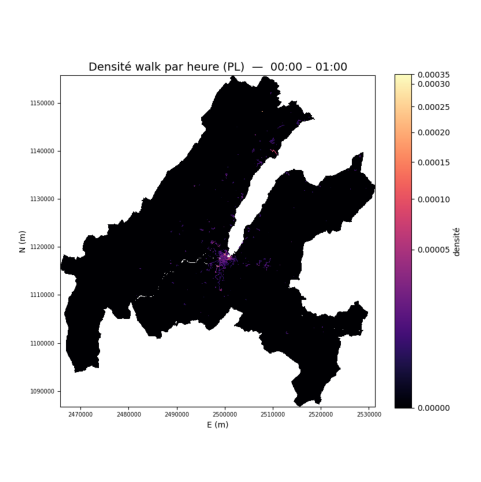

In [16]:
def render(arr, extent, label):
    fig, ax = plt.subplots(figsize=(8, 8), dpi=DPI)
    im = ax.imshow(arr, cmap=cmap, norm=norm, extent=extent, interpolation="nearest")
    ax.set_title(f"{TITLE}  —  {label}", fontsize=14)
    ax.set_xlabel("E (m)"); ax.set_ylabel("N (m)")
    ax.ticklabel_format(style="plain", useOffset=False)
    ax.tick_params(labelsize=7)
    fig.colorbar(im, ax=ax, shrink=0.75, label="densité")
    fig.tight_layout()
    fig.canvas.draw()
    img = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
    plt.close(fig)
    return img

images = [render(a, e, label_from_name(f.name)) for a, e, f in zip(frames, extents, files)]

# aperçu de la première image
plt.figure(figsize=(6, 6)); plt.imshow(images[0]); plt.axis("off"); plt.show()

## Export GIF

In [17]:
imageio.mimsave(OUTPUT_GIF, images, duration=1000 / FPS, loop=0)   # loop=0 : boucle infinie
print(f"GIF écrit : {OUTPUT_GIF.resolve()}  ({OUTPUT_GIF.stat().st_size/1e6:.1f} Mo)")

GIF écrit : /Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/output/PL_output/density_walk_hourly/animation.gif  (0.6 Mo)


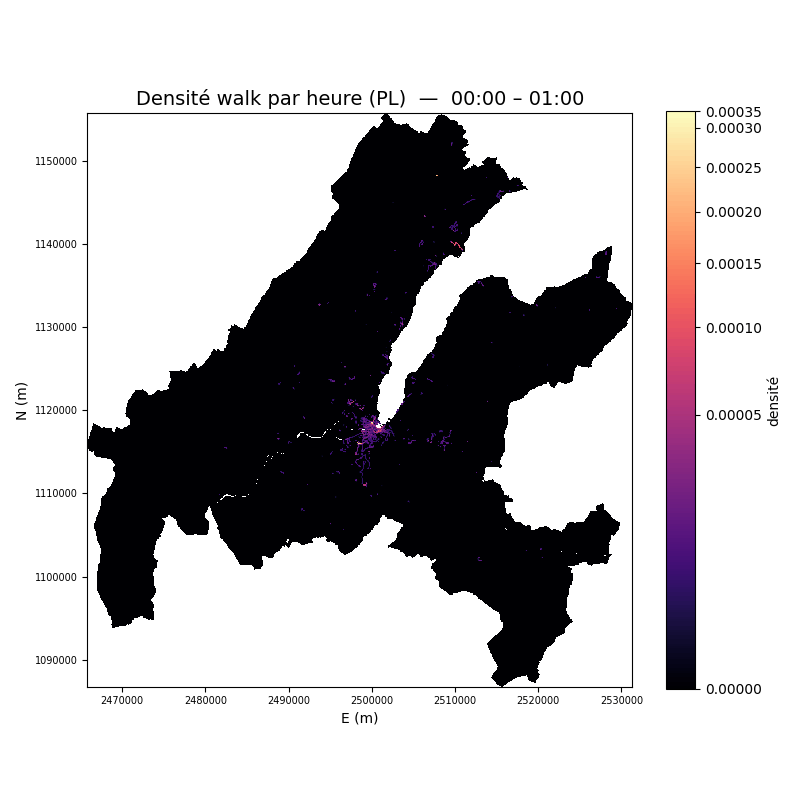

In [18]:
# Affichage dans le notebook
from IPython.display import Image, display
display(Image(filename=str(OUTPUT_GIF)))